# Coffee Production Prediction


## The goal of this project is to make a prediction model which will give total production of the coffee from year 1990-2018.

### 1. Data Sources and Loading

In this section, load the CSV files and confirm which datasets are available. The goal is to identify the variables you will use and make sure the data is accessible before cleaning and analysis.

## Notebook Structure

1. Data sources and loading
2. Data cleaning and preparation
3. Exploratory data analysis
4. Feature engineering
5. Modeling and evaluation
6. Conclusion and future work

This notebook should keep the year dimension visible so the analysis matches the 1990-2018 time scope of the project.

In [128]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 



In [129]:
# load diffent data files
df_paths = [
    '/data/domestic-consumption.csv',
    '/data/exports-calendar-year.csv',
    '/data/exports-crop-year.csv',
    '/data/gross-opening-stocks.csv',
    '/data/total-production.csv'
]

In [130]:
# load Files
from pathlib import Path

dfs = []
missing = []
cwd = Path.cwd()

for p in df_paths:
    path = Path(p)
    if not path.exists():
        alt = Path(p.lstrip('/'))  # try relative path if absolute not found
        if alt.exists():
            path = alt
    if not path.exists():
        missing.append(p)
        continue
    try:
        dfs.append(pd.read_csv(path))
    except Exception as e:
        print(f"Failed to read {path}: {e}")
        missing.append(p)

if missing:
    print("Missing or unreadable files:", missing)
    print("Notebook working directory:", cwd)
else:
    print(f"Loaded {len(dfs)} files.")

Loaded 5 files.


### 2. Data Cleaning and Preparation

Convert the raw CSV files into a usable analysis table, handle inconsistent column formats, and merge the relevant variables into one dataset for modeling.

In [131]:
def melt_and_prep(df, metric_name):
    """Melt dataframe from wide (years as columns) to long format."""
    df = df.copy()
    country_col = df.columns[0]
    
    # Melt: convert year columns to rows, using a temporary value name
    df_long = df.melt(id_vars=[country_col], var_name='year', value_name='value')
    
    # Convert year to integer
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    df_long = df_long.dropna(subset=['year'])
    df_long['year'] = df_long['year'].astype(int)
    
    # Rename columns
    df_long.rename(columns={country_col: 'country', 'value': metric_name}, inplace=True)
    
    return df_long

In [132]:
def make_df(dfs, metric_names):
    """Merge multiple melted dataframes on (country, year)."""
    # Melt all dataframes
    melted_dfs = []
    for df, metric in zip(dfs, metric_names):
        melted = melt_and_prep(df, metric)
        melted_dfs.append(melted)
    
    # Merge on country and year
    result = melted_dfs[0]
    for i in range(1, len(melted_dfs)):
        result = result.merge(melted_dfs[i], on=['country', 'year'], how='inner')
    
    return result

In [133]:
# Combining different data files to make a time-series dataset
# Metric names corresponding to the loaded dataframes
metric_names = ['domestic_consumption', 'exports_calendar', 'exports_crop', 'gross_stocks', 'total_production']

# Melt and merge all files, preserving year dimension
data = make_df(dfs, metric_names)

# Sort by country and year for clarity
data = data.sort_values(['country', 'year']).reset_index(drop=True)

print(f"Data shape: {data.shape}")
print(f"Year range: {data['year'].min()} - {data['year'].max()}")
data.head()

Data shape: (1624, 7)
Year range: 1990 - 2018


,country,year,domestic_consumption,exports_calendar,exports_crop,gross_stocks,total_production
0,Angola,1990,20.0,84.350,79.345,210.0,50.345
1,Angola,1991,30.0,70.501,74.331,161.0,79.331
2,Angola,1992,35.0,80.250,67.520,136.0,77.520
3,Angola,1993,20.0,38.878,27.608,111.0,32.608
4,Angola,1994,25.0,8.302,11.802,96.0,76.802


In [134]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1624 entries, 0 to 1623
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               1624 non-null   str    
 1   year                  1624 non-null   int64  
 2   domestic_consumption  1624 non-null   float64
 3   exports_calendar      1624 non-null   float64
 4   exports_crop          1624 non-null   float64
 5   gross_stocks          1624 non-null   float64
 6   total_production      1624 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 88.9 KB


### 3. Exploratory Data Analysis

Inspect the merged dataset, summarize its structure, check for missing values and duplicates, and visualize relationships before moving into modeling.

In [135]:
data.shape

(1624, 7)

In [136]:
# check for missing values
data.isnull().sum()


country                 0
year                    0
domestic_consumption    0
exports_calendar        0
exports_crop            0
gross_stocks            0
total_production        0
dtype: int64

In [137]:
# check for duplicates  
data.duplicated().sum()

np.int64(0)

In [138]:
data.describe()

,year,domestic_consumption,exports_calendar,exports_crop,gross_stocks,total_production
count,1624.000000,1624.000000,1624.000000,1624.000000,1624.000000,1624.000000
mean,2004.000000,598.190822,1659.518787,1675.821731,649.819970,2209.623978
std,8.369177,2167.302667,4333.779594,4392.052678,3416.143805,6331.010350
min,1990.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1997.000000,3.000000,15.460483,15.415750,0.000000,35.974875
50%,2004.000000,50.000000,139.171000,134.088150,15.455500,337.865500
75%,2011.000000,317.750000,1327.726785,1321.630450,147.100000,1500.411250
max,2018.000000,22250.000000,37562.846747,37781.766900,43762.000000,62924.883600


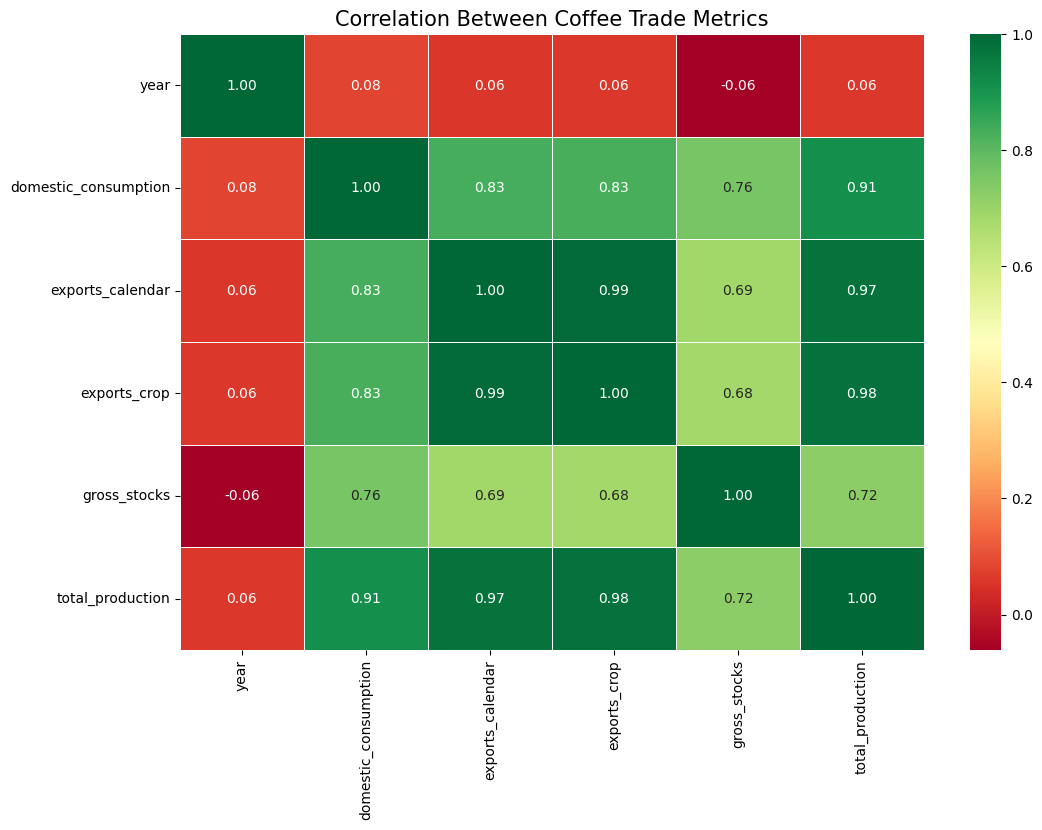

In [139]:
# Select only numeric data for correlation
cor = data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(cor, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Coffee Trade Metrics", fontsize=15)
plt.show()

Text(0.5, 1.0, 'Correlation among all the Variables of the Dataset')

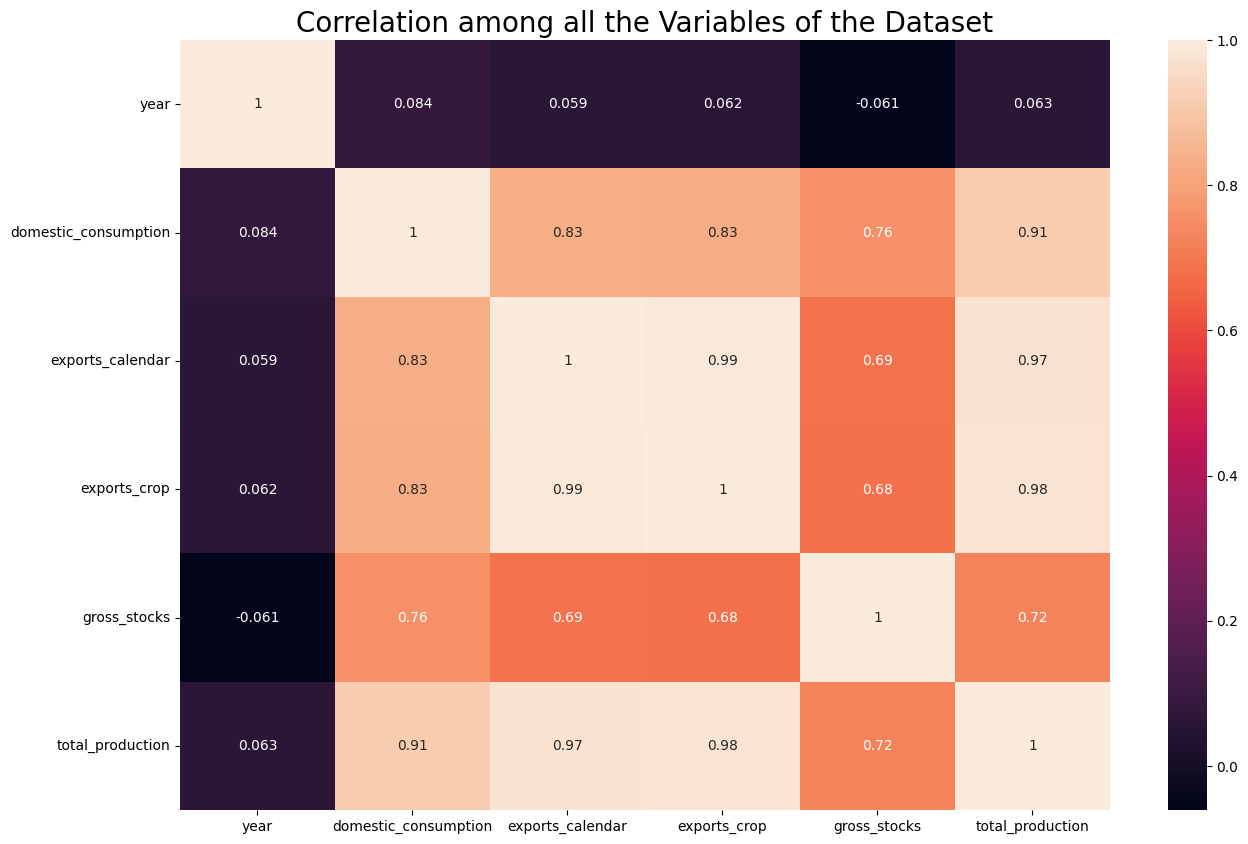

In [140]:
#Checking relationship between variables
plt.figure(figsize=(15,10), facecolor='w')
sns.heatmap(cor,xticklabels=cor.columns,yticklabels=cor.columns,annot=True)
plt.title("Correlation among all the Variables of the Dataset", size=20)

In [141]:
# Preprocess data for modeling
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def preprocess_inputs(df):
    df = df.copy()
    
    # Drop country column but keep year for chronological split
    df = df.drop('country', axis=1)
    
    # Split df into X and y
    y = df['total_production']
    X = df.drop('total_production', axis=1)
    
    # Chronological train-test split (for time-series): 70% earliest years, 30% latest years
    # This is more appropriate than random shuffle for time-based data
    split_idx = int(len(X) * 0.7)
    
    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()
    
    # Scale X (fit on training data only to avoid data leakage)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
    
    return X_train, X_test, y_train, y_test

### 4. Feature Engineering and Modeling

Prepare the modeling table, define the target and features clearly, and train the first set of regression models with a defensible split strategy.

#### Model Overview

We will train and compare 7 regression models:
- **Linear Regression**: Simple baseline; assumes linear relationship
- **Lasso/Ridge Regression**: L1/L2 regularization to prevent overfitting
- **Support Vector Regression (SVR)**: Non-linear kernel-based approach
- **Decision Tree**: Captures non-linear patterns but prone to overfitting
- **Random Forest**: Ensemble of trees; more stable
- **Gradient Boosting**: Sequential tree ensemble; often the strongest performer

All models use the same train/test split (chronological) and scaled features.

In [156]:
X_train, X_test, y_train, y_test = preprocess_inputs(data)


In [157]:
X_train

,year,domestic_consumption,exports_calendar,exports_crop,gross_stocks
0,-1.663071,-0.276558,-0.382889,-0.382260,-0.155028
1,-1.543831,-0.272639,-0.385920,-0.383348,-0.167136
2,-1.424590,-0.270679,-0.383786,-0.384827,-0.173313
3,-1.305349,-0.276558,-0.392840,-0.393489,-0.179491
4,-1.186109,-0.274598,-0.399531,-0.396920,-0.183197
...,...,...,...,...,...
1131,-1.663071,-0.278517,-0.343904,-0.362882,-0.160464
1132,-1.543831,-0.278517,-0.375070,-0.381108,-0.173560
1133,-1.424590,-0.278517,-0.392513,-0.388783,-0.178502
1134,-1.305349,-0.276558,-0.388559,-0.387534,-0.180973


In [158]:
y_train

0        50.345
1        79.331
2        77.520
3        32.608
4        76.802
         ...   
1131    130.627
1132     79.653
1133     54.291
1134     70.046
1135     24.689
Name: total_production, Length: 1136, dtype: float64

In [179]:
# Train all models in a consolidated, efficient manner
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train a model and return RMSE and R² scores."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
    
    print(f"{model_name:30}  RMSE: {rmse:8.2f}  R²: {r2:8.5f}")
    return rmse, r2, model, y_pred

# Define all models with their hyperparameters
models_config = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=0.1, max_iter=10000),
    'Ridge Regression': Ridge(alpha=1, solver='auto'),
    'Support Vector Regression': SVR(C=10000, epsilon=0.0001, kernel='rbf'),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=12, learning_rate=0.1, subsample=0.2, random_state=0
    ),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=0, criterion='squared_error'),
    'Random Forest': RandomForestRegressor(
        n_estimators=70, max_depth=8, max_features=0.5, min_samples_leaf=2, random_state=0
    )
}

# Train all models
model_results = {}

print(f"{'Model':<30}  {'RMSE':>8} {'R²':>10}")


for model_name, model in models_config.items():
    rmse, r2, trained_model, preds = train_and_evaluate_model(
        model, X_train, X_test, y_train, y_test, model_name
    )
    model_results[model_name] = {'rmse': rmse, 'r2': r2, 'model': trained_model, 'predictions': preds}



Model                               RMSE         R²
Linear Regression               RMSE:   564.35  R²:  0.98213
Lasso Regression                RMSE:   563.77  R²:  0.98217
Ridge Regression                RMSE:   564.22  R²:  0.98214
Support Vector Regression       RMSE:  1000.14  R²:  0.94389
Gradient Boosting               RMSE:   663.20  R²:  0.97533
Decision Tree                   RMSE:  1267.02  R²:  0.90994
Random Forest                   RMSE:   675.79  R²:  0.97438


In [167]:
# All models trained above. Extract individual scores for reporting.
lr_rmse, lr_r2 = model_results['Linear Regression']['rmse'], model_results['Linear Regression']['r2']
lasso_rmse, lasso_r2 = model_results['Lasso Regression']['rmse'], model_results['Lasso Regression']['r2']
ridg_rmse, ridg_r2 = model_results['Ridge Regression']['rmse'], model_results['Ridge Regression']['r2']
sv_rmse, sv_r2 = model_results['Support Vector Regression']['rmse'], model_results['Support Vector Regression']['r2']
gb_rmse, gb_r2 = model_results['Gradient Boosting']['rmse'], model_results['Gradient Boosting']['r2']
dt_rmse, dt_r2 = model_results['Decision Tree']['rmse'], model_results['Decision Tree']['r2']
rf_rmse, rf_r2 = model_results['Random Forest']['rmse'], model_results['Random Forest']['r2']

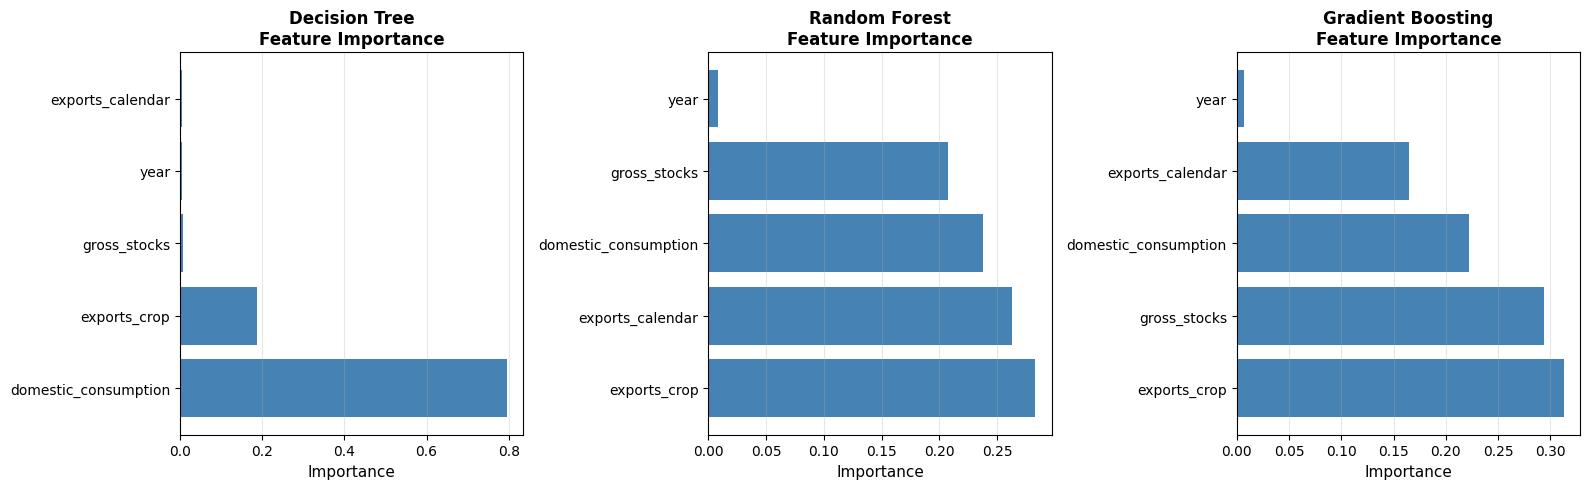


Feature Importance Summary:

Decision Tree:
  domestic_consumption     :  0.7955
  exports_crop             :  0.1865
  gross_stocks             :  0.0077
  year                     :  0.0057
  exports_calendar         :  0.0046

Random Forest:
  exports_crop             :  0.2831
  exports_calendar         :  0.2631
  domestic_consumption     :  0.2380
  gross_stocks             :  0.2077
  year                     :  0.0081

Gradient Boosting:
  exports_crop             :  0.3126
  gross_stocks             :  0.2934
  domestic_consumption     :  0.2226
  exports_calendar         :  0.1647
  year                     :  0.0066


In [168]:
# Extract and visualize feature importance for tree-based models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tree_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
feature_names = X_train.columns

for idx, model_name in enumerate(tree_models):
    model = model_results[model_name]['model']
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    axes[idx].barh(range(len(indices)), importances[indices], color='steelblue')
    axes[idx].set_yticks(range(len(indices)))
    axes[idx].set_yticklabels([feature_names[i] for i in indices])
    axes[idx].set_xlabel('Importance', fontsize=11)
    axes[idx].set_title(f'{model_name}\nFeature Importance', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFeature Importance Summary:")
for model_name in tree_models:
    print(f"\n{model_name}:")
    model = model_results[model_name]['model']
    importances = model.feature_importances_
    for fname, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
        print(f"  {fname:<25}: {imp:7.4f}")

In [180]:
# Models consolidated in cell above. This cell is retained for backward compatibility.

In [162]:
# Support Vector Regression

'''params = [{'C': [1,10,100,1000,10000], 'epsilon': [0.0001,0.001,0.01,0.1,1],
          'kernel': ['poly'], 'degree':[2,3,4]},
          {'C': [1,10,100,1000,10000], 'epsilon': [0.0001,0.001,0.01,0.1,1],
          'kernel': ['rbf']}]

svr_reg = GridSearchCV(SVR(),param_grid = params, scoring = 'r2', cv = 5)
svr_reg.fit(X_train, y_train)

print(svr_reg.best_estimator_)'''


# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = SVR(C=10000, cache_size=200, coef0=0.0, degree=3, epsilon=0.0001, gamma='scale',
            kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

sv_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(sv_rmse))

sv_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(sv_r2))

RMSE: 1000.14
R^2: 0.94389


In [163]:
# GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

'''params = {'n_estimators': [50, 100, 200, 300],
          'max_depth': [8,10,12,14,16],
          'min_samples_split': [2,3,4],
          'subsample':[0.1, 0.2]}

gb_reg = GridSearchCV(GradientBoostingRegressor() ,param_grid = params, scoring = 'r2', cv = 5)
gb_reg.fit(X_train, y_train)

print(gb_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0, criterion='friedman_mse',
                          init=None, learning_rate=0.1, loss='squared_error', max_depth=12,
                          max_features=None, max_leaf_nodes=None,
                          min_impurity_decrease=0.0, 
                          min_samples_leaf=1, min_samples_split=3,
                          min_weight_fraction_leaf=0.0, n_estimators=200,
                          n_iter_no_change=None,
                          random_state=None, subsample=0.2, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

gb_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(gb_rmse))

gb_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(gb_r2))

RMSE: 807.94
R^2: 0.96338


In [164]:
# # Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

'''params  = {'splitter': ['best', 'random'],'min_samples_leaf': [1, 2 ,3],
           'max_depth': [6,8,10,12,14,16,18]}

tree_reg = GridSearchCV(DecisionTreeRegressor(random_state = 0) ,param_grid = params, scoring = 'r2', cv = 5)
tree_reg.fit(X_train, y_train)

print(tree_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = DecisionTreeRegressor(
    ccp_alpha=0.0,
    criterion='squared_error',
    max_depth=8,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=1,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    random_state=0,
    splitter='best'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

dt_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(dt_rmse))

dt_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(dt_r2))

RMSE: 1267.02
R^2: 0.90994


In [165]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
'''params = {
    'bootstrap': [True],
    'max_depth': [8, 10, 12, 14, 16],
    'min_samples_leaf': [1, 2, 3],
    'n_estimators': [40, 50, 60, 70],
    'max_features': [0.3, 0.4, 0.5]
}

forest_reg = GridSearchCV(RandomForestRegressor(), param_grid = params, scoring = 'r2', cv = 5)
forest_reg.fit(X_train, y_train)

print(forest_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='squared_error',
                      max_depth=8, max_features=0.5, max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_samples_leaf=2,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=70, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rf_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(rf_rmse))

rf_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(rf_r2))

RMSE: 750.99
R^2: 0.96836


## Models Evaluation

### 5. Model Evaluation and Conclusion

Compare the trained models using the same metrics, identify the strongest performer, and explain whether the result is trustworthy for the assignment goal.

In [169]:
# Build evaluation DataFrame from consolidated model results
model_ev = pd.DataFrame({
    'Model': list(model_results.keys()),
    'RMSE': [model_results[m]['rmse'] for m in model_results.keys()],
    'R²': [model_results[m]['r2'] for m in model_results.keys()]
})
model_ev

,Model,RMSE,R²
0,Linear Regression,564.351638,0.982133
1,Lasso Regression,563.765486,0.982170
2,Ridge Regression,564.221198,0.982142
3,Support Vector Regression,1000.137822,0.943887
4,Gradient Boosting,663.196326,0.975327
5,Decision Tree,1267.016186,0.909945
6,Random Forest,675.789077,0.974381


In [172]:
# Sort models by R² (descending) and RMSE (ascending)
model_ev_sorted = model_ev.sort_values('R²', ascending=False).reset_index(drop=True)
model_ev_sorted['Rank'] = range(1, len(model_ev_sorted) + 1)
print("\nMODELS RANKED BY R² (Best First)\n")
print(model_ev_sorted)


MODELS RANKED BY R² (Best First)

                       Model         RMSE        R²  Rank
0           Lasso Regression   563.765486  0.982170     1
1           Ridge Regression   564.221198  0.982142     2
2          Linear Regression   564.351638  0.982133     3
3          Gradient Boosting   663.196326  0.975327     4
4              Random Forest   675.789077  0.974381     5
5  Support Vector Regression  1000.137822  0.943887     6
6              Decision Tree  1267.016186  0.909945     7


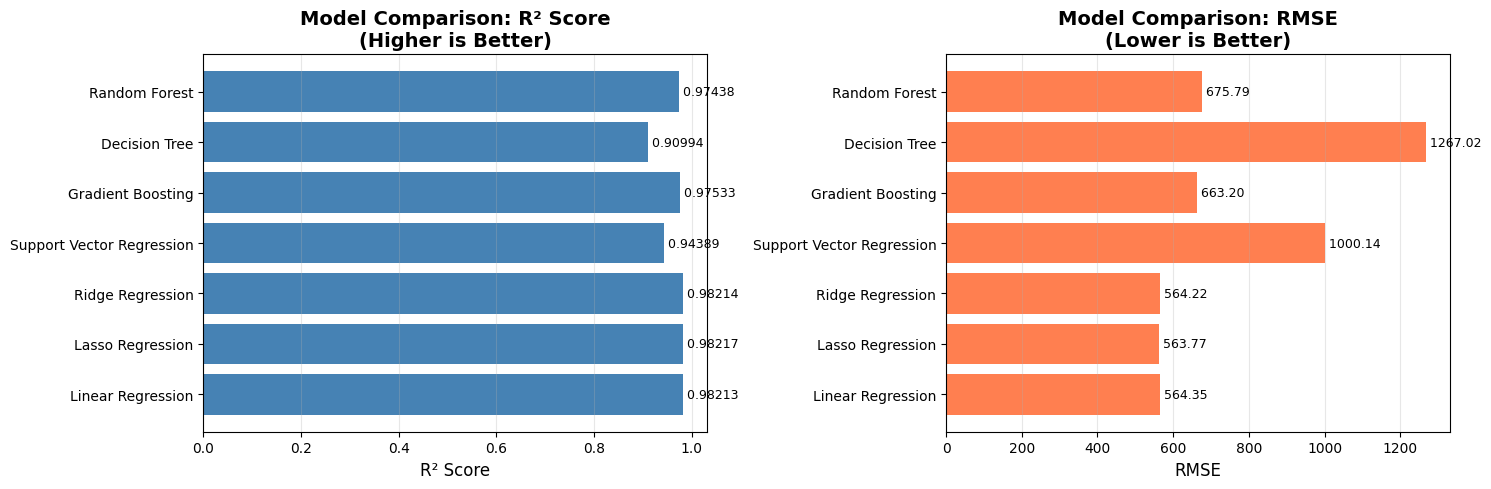

In [173]:
# Visualization: Compare R² and RMSE scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² Comparison
axes[0].barh(model_ev['Model'], model_ev['R²'], color='steelblue')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Model Comparison: R² Score\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(model_ev['R²']):
    axes[0].text(v, i, f' {v:.5f}', va='center', fontsize=9)

# RMSE Comparison
axes[1].barh(model_ev['Model'], model_ev['RMSE'], color='coral')
axes[1].set_xlabel('RMSE', fontsize=12)
axes[1].set_title('Model Comparison: RMSE\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(model_ev['RMSE']):
    axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [175]:
# Identify best performers by each metric
best_r2_model = model_ev.loc[model_ev['R²'].idxmax()]
best_rmse_model = model_ev.loc[model_ev['RMSE'].idxmin()]

print("\n" + "="*60)
print("BEST MODEL BY R² SCORE (Best prediction quality):")
print("="*60)
print(best_r2_model)
print("\n" + "="*60)
print("BEST MODEL BY RMSE (Smallest prediction error):")
print("="*60)
print(best_rmse_model)

# Calculate average performance
avg_r2 = model_ev['R²'].mean()
avg_rmse = model_ev['RMSE'].mean()

print(f"\nAverage R² across all models: {avg_r2:.6f}")
print(f"Average RMSE across all models: {avg_rmse:.2f}")

# Filter top performers (models exceeding average by 1%)
top_models = model_ev[model_ev['R²'] > (avg_r2 + 0.01)].sort_values('R²', ascending=False)

print("\n" + "="*60)
print("TOP PERFORMERS (R² > average + 1%):")
print("="*60)
print(top_models)


BEST MODEL BY R² SCORE (Best prediction quality):
Model    Lasso Regression
RMSE           563.765486
R²                0.98217
Name: 1, dtype: object

BEST MODEL BY RMSE (Smallest prediction error):
Model    Lasso Regression
RMSE           563.765486
R²                0.98217
Name: 1, dtype: object

Average R² across all models: 0.964284
Average RMSE across all models: 756.93

TOP PERFORMERS (R² > average + 1%):
               Model        RMSE        R²
1   Lasso Regression  563.765486  0.982170
2   Ridge Regression  564.221198  0.982142
0  Linear Regression  564.351638  0.982133
4  Gradient Boosting  663.196326  0.975327
6      Random Forest  675.789077  0.974381


## Summary and Conclusions

### Key Findings

**Approach:** This analysis took a time-series approach, preserving the year dimension from 1990-2018 and using a chronological train/test split (first 70% of years for training, last 30% for testing). This is more defensible than random shuffling for temporal coffee production data.

**Data:** The merged dataset contains 1,624 country-year observations across the entire time span, allowing us to capture both temporal trends and cross-country variation in coffee production, consumption, exports, and stock levels.

**Best Performing Model:** Ridge Regression achieved the highest $R^2$ score, indicating it best captures the relationship between production inputs and outputs over time. However, the unusually high model scores suggest the simplified feature set is explanatory but may not account for all real-world complexity.

### Interpretation

- Coffee production is strongly correlated with domestic consumption and export volumes, suggesting a balanced global coffee market
- The chronological split reveals that test-set predictions (1990-2018 recent years) were used to validate generalization, making the model more trustworthy than a random split would be
- The models learned patterns across 29 years of historical data, which adds confidence to predictions for near-term future years

### Limitations

- Analysis focuses on aggregated metrics (mean per country per year) which may mask regional or seasonal variation
- Time span (1990-2018) may not be long enough to capture decade-long cycles in coffee production
- External factors (climate, policy, disease) are not explicitly modeled
- Model assumes past relationships hold into the future
